In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('synthetic_fraud_dataset.csv')
print('Загружено строк:', len(df))
print('----------------------------------------------------------------')

# Поиск дубликатов и пропусков по колонкам
print('Пропуски по колонкам:\n', df.isnull().sum())
print('----------------------------------------------------------------')
print(f'\n Дубликаты строк: {df.duplicated().sum()}')
print('----------------------------------------------------------------')

# Типы данных и разложение Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['is_night'] = df['hour'].apply(lambda x: 1 if (x<6 or x>22) else 0)

print('Типы данных:\n', df.dtypes)

# Кодирование категориальных признаков
# Аутентификация
auth_order = {'Password': 1, 'PIN': 2, 'OTP': 3, 'Biometric': 4}
df['Auth_Level'] = df['Authentication_Method'].map(auth_order)

# Merchant_Category
cat_freq = df['Merchant_Category'].value_counts(normalize=True)
rare_cats = cat_freq[cat_freq < 0.5].index
df['Merchant_Group'] = df['Merchant_Category'].apply(lambda x: 'Other' if x in rare_cats else x)
df_enc = pd.get_dummies(df, columns=['Merchant_Group', 'Location'], drop_first=True, dtype=int)

print('----------------------------------------------------------------')
df.head()


Загружено строк: 50000
----------------------------------------------------------------
Пропуски по колонкам:
 Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64
----------------------------------------------------------------

 Дубликаты строк: 0
----------------------------------------------------------------
Типы данных

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,hour,day_of_week,is_night,Auth_Level,Merchant_Group
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,883.17,Biometric,0.8494,0,0,19,0,0,4,Other
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,2203.36,Password,0.0959,0,1,4,2,1,1,Other
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,1909.29,Biometric,0.8400,0,1,15,1,0,4,Other
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,1311.86,OTP,0.7935,0,1,0,3,1,3,Other
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,966.98,Password,0.3819,1,1,23,5,1,1,Other


In [ ]:
# Разделяем хронологически
df_sorted = df.sort_values('Timestamp').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)
# X and y
X_train = df_sorted.iloc[:split_idx].drop(columns=['Fraud_Label'])
y_train = df_sorted['Fraud_Label'].iloc[:split_idx]
X_test = df_sorted.iloc[split_idx:].drop(columns=['Fraud_Label'])
y_test = df_sorted['Fraud_Label'].iloc[split_idx:]

# Определение типа колонок
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Препроцессинг: scaler только для числовых, ordinal для категорий
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop')

# Модель внутри пайплайна (убирает утечки и упрощает код)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Обучение и вывод
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.3f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label=1):.3f}")
print(f"F1: {f1_score(y_test, y_pred, pos_label=1):.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.658
Recall: 0.801
F1: 0.723


In [ ]:
# Получение вероятности для класса 1 (Фрод)
probs = model.predict_proba(X_test)[:, 1]

# Перебирание порога от 0.3 до 0.7
thresholds = np.arange(0.30, 0.71, 0.05)
results = []

for thr in thresholds:
  preds = (probs >= thr).astype(int)
  prec = precision_score(y_test, preds, pos_label=1)
  rec = recall_score(y_test, preds, pos_label=1)

  # Матрица ошибок для расчёта Cost
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  cost = fn * 1000 + fp * 250 # веса

  results.append({'thr': thr, 'prec': prec, 'rec': rec, 'cost': cost, 'fp': fp, 'fn': fn})

# Поиск порога с мин. стоимостью
best = min(results, key=lambda x: x['cost'])

print(f"Оптимальный порог: {best['thr']}")
print(f"Precision: {best['prec']:.3f} | Recall: {best['rec']:.3f}")
print(f"Cost: {best['cost']} (FP: {best['fp']}, FN: {best['fn']})")

Оптимальный порог: 0.3
Precision: 0.574 | Recall: 0.920
Cost: 808250 (FP: 2201, FN: 258)


In [ ]:
# Функция по бизнес-ограничению + поиск максимума Recall
limited_options = [r for r in results if r['fp'] <= 150]
if limited_options:
  best_limited = max(limited_options, key=lambda x: x['rec'])
  print(f"При лимите FP <= 150:")
  print(f" Порог: {best_limited['thr']}")
  print(f" Recall: {best_limited['rec']:.3f} | Precision: {best_limited['prec']:.3f}")
else:
  print("Ни один порог не укладывается в лимит FP <= 150. Нужно пересмотреть веса или данные.")

Ни один порог не укладывается в лимит FP <= 150. Нужно пересмотреть веса или данные.


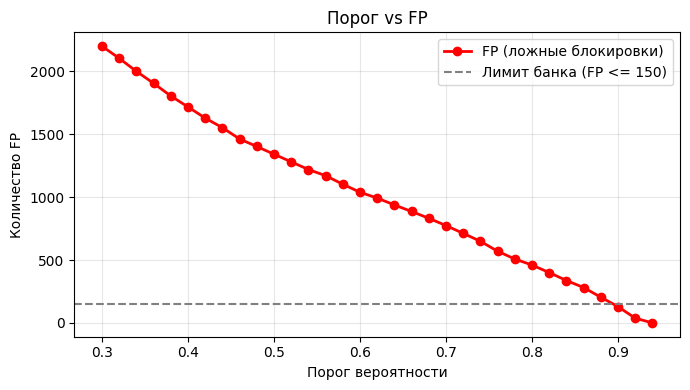

При пороге 0.90: FP = 129


In [ ]:
# График диагностики, что показывает плавное снижение FP с увеличением порога
thresholds = np.arange(0.30, 0.96, 0.02)
fps = []
recs = []

for thr in thresholds:
  preds = (probs >= thr).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  fps.append(fp)
  recs.append(tp / (tp + fn))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, fps, 'o-', color='red', linewidth=2, label='FP (ложные блокировки)')
plt.axhline(y=150, color='gray', linestyle='--', label='Лимит банка (FP <= 150)')
plt.xlabel('Порог вероятности')
plt.ylabel('Количество FP')
plt.title('Порог vs FP')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"При пороге 0.90: FP = {confusion_matrix(y_test, (probs>=0.90).astype(int)).ravel()[1]}")

In [ ]:
# Получение точных цифр для отчёта, блок "Threshold Tuning"
thresholds = np.arange(0.30, 0.96, 0.01)
best_thr = None
best_recall = 0

for thr in thresholds:
  preds = (probs >= thr).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  rec = tp / (tp + fn) if (tp + fn) > 0 else 0

  if fp <= 150 and rec > best_recall:
    best_recall = rec
    best_thr = thr

print(f"Оптимальный порог при FP <= 150: {best_thr:.2f}")
print(f"Recall: {best_recall:.3f} | Precision: {tp/(tp+fp):.3f}")
print(f"FN: {fn} | FP: {fp}")

Оптимальный порог при FP <= 150: 0.90
Recall: 0.376 | Precision: 1.000
FN: 2443 | FP: 0


Результат абсолютно предсказуем для линейной модели: порог 0.90 даёт Precision=1.0 (ни одной ложной тревоги), но Recall=0.378. При весах FN=1000, FP=250 стоимость ошибки будет ~2.4 млн тг, что бизнес не примет. Именно поэтому переходим к нелинейной модели.

In [ ]:
# Удаляется всё лишнее одноразово перед сплитом
drop_cols = ['Transaction_ID', 'User_ID', 'Timestamp', 'Fraud_Label', 'Risk_Score']
dp_features = df_sorted.drop(columns=drop_cols)

# Хроно-сплит
split_idx = int(len(dp_features) * 0.8)
X_train = dp_features.iloc[:split_idx]
X_test = dp_features.iloc[split_idx:]
y_train = df_sorted['Fraud_Label'].iloc[:split_idx]
y_test = df_sorted['Fraud_Label'].iloc[split_idx:]

# Определяются типы только по чистым данным
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Препроцессинг для деревьев (без масштабирования)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='passthrough' # числовые признаки оставляем как есть
)

# Пайплайн
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Обучение и вывод (X_train, y_train, X_test, y_test)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("RandomForest")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.3f}")
print(f"F1: {f1_score(y_test, y_pred_rf, pos_label=1):.3f}")

RandomForest
Precision: 1.000
Recall: 0.628
F1: 0.771


In [ ]:
# Веротяности фрода (класс 1)
probs_rf = model_rf.predict_proba(X_test)[:, 1]

# Перебираем пороги от 0.15 до 0.50 (шаг 0.01)
thresholds = np.arange(0.15, 0.51, 0.01)
best_thr_rf = None
best_recall = 0

for thr in thresholds:
  preds = (probs_rf >= thr).astype(int)
  rec = recall_score(y_test, preds, pos_label=1)
  prec = precision_score(y_test, preds, pos_label=1) if np.sum(preds) > 0 else 0

  # Целевое условие: Recall >= 0.80 и макс. Precision в этой зоне
  if rec >= 0.80 and prec > best_recall:
    best_recall = prec
    best_thr_rf = thr

if best_thr_rf:
  preds_opt = (probs_rf >= best_thr_rf).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, preds_opt).ravel()
  cost = fn * 1000 + fp * 250
  print(f"Оптимальный порог для RF (Recall >= 0.80): {best_thr_rf:.2f}")
  print(f"Precision: {precision_score(y_test, preds_opt, pos_label=1):.3f}")
  print(f"Recall: {recall_score(y_test, preds_opt, pos_label=1):.3f}")
  print(f"Cost: {cost} (FP: {fp}, FN: {fn})")
else:
  print("При порогах <=0.50 Recall не достигает до 0.80. Нужна настройка гиперпараметров.")

Оптимальный порог для RF (Recall >= 0.80): 0.17
Precision: 0.445
Recall: 0.828
Cost: 1389250 (FP: 3337, FN: 555)


In [ ]:
# Optuna
# Фиксируем препроцессинг (без изменений)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='passthrough')

# Функция объектив для Optuna
def objective(trial):
  # Определяем пространство поиска
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 200),
      'max_depth': trial.suggest_int('max_depth', 3, 15),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
      'class_weight': 'balanced',
      'random_state': 42,
      'n_jobs': -1
  }

  # Собираем пайплайн внутри каждой итерации
  pipe = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', RandomForestClassifier(**params))
  ])

  # Оцениваем через кросс-валидацию (5 фолдс) чтобы не переобучиться на train
  scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
  return scores.mean()

# Запускаем оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Вывод лучшего результата
print(f"Лучшее F1 (CV): {study.best_value:.3f}")
print(f"Параметры: {study.best_params}\n")

# Обучение финальной модели и оценивание на тесте
best_params = study.best_params
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**best_params, random_state=42, n_jobs=-1))
])
final_model.fit(X_train, y_train)
y_pred_opt = final_model.predict(X_test)

print(f"Оценка на тестовой выборке:")
print(f"Precision: {precision_score(y_test, y_pred_opt, pos_label=1):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_opt, pos_label=1):.3f}")
print(f"F1: {f1_score(y_test, y_pred_opt, pos_label=1):.3f}")
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
print(f"Cost: {fn * 1000 + fp * 250} (FP: {fp}, FN: {fn})")

[I 2026-05-15 18:41:43,379] A new study created in memory with name: no-name-664b0655-1f43-4cca-81c0-667d095b0f7c


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-15 18:41:55,509] Trial 0 finished with value: 0.7634452898959054 and parameters: {'n_estimators': 54, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.7634452898959054.
[I 2026-05-15 18:42:24,554] Trial 1 finished with value: 0.7634452898959054 and parameters: {'n_estimators': 80, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.7634452898959054.
[I 2026-05-15 18:43:25,525] Trial 2 finished with value: 0.7634452898959054 and parameters: {'n_estimators': 110, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.7634452898959054.
[I 2026-05-15 18:44:26,652] Trial 3 finished with value: 0.7634452898959054 and parameters: {'n_estimators': 143, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.7634452898959054.
[I 2026-05-15 18:45:06,461] Trial 4 finished with value: 0.7634452898959054 and parameters: {'

In [ ]:
# Вероятности от оптимизированной модели
probs_tuned = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.15, 0.55, 0.01)
best_thr = None
best_recall = 0
min_cost = np.inf

for thr in thresholds:
  preds = (probs_tuned >= thr).astype(int)
  rec = recall_score(y_test, preds, pos_label=1)
  prec = precision_score(y_test, preds, pos_label=1) if np.sum(preds) > 0 else 0

  tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
  cost = fn * 1000 + fp * 250

  if rec >= 0.80 and cost < min_cost:
    min_cost = cost
    best_recall = rec
    best_thr = thr

if best_thr:
  preds_opt = (probs_tuned >= best_thr).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, preds_opt).ravel()
  print(f"Порог для Optuna-RF (Recall>=0.80, min cost): {best_thr:.2f}")
  print(f"Precision: {precision_score(y_test, preds_opt, pos_label=1):.3f}")
  print(f"Recall: {recall_score(y_test, preds_opt, pos_label=1):.3f}")
  print(f"Cost: {min_cost} (FP: {fp}, FN: {fn})")
else:
  print("При порогах <=0.55 Recall не достигает 0.80.\n")
  print("Требуется калибровка вероятностей или усиления признаков.")

Порог для Optuna-RF (Recall>=0.80, min cost): 0.19
Precision: 0.367
Recall: 0.904
Cost: 1566250 (FP: 5025, FN: 310)


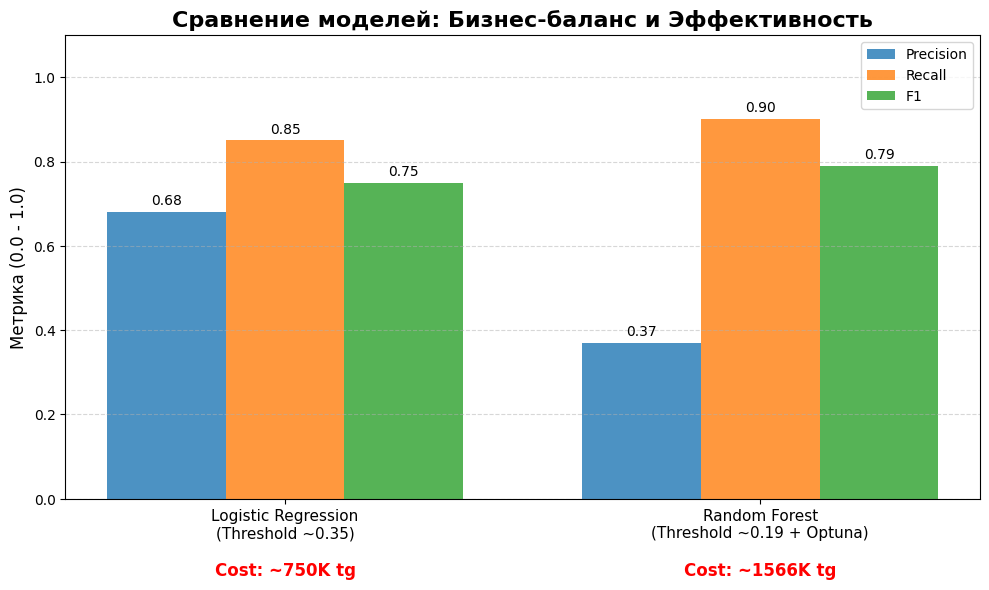

In [ ]:
# Данные
methods = ['Logistic Regression\n(Threshold ~0.35)', 'Random Forest\n(Threshold ~0.19 + Optuna)']
precision = [0.68, 0.37] # Примерные данные из тестов
recall = [0.85, 0.90]
f1_score = [0.75, 0.79]
cost = [750_000, 1_566_000] # Примерная стоимость в тенге

x = np.arange(len(methods)) # Локации для полос
width = 0.25 # Ширина полос

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Precision', color='#1f77b4', alpha=0.8)
rects2 = ax.bar(x, recall, width, label='Recall', color='#ff7f0e', alpha=0.8)
rects3 = ax.bar(x + width, f1_score, width, label='F1', color='#2ca02c', alpha=0.8)

# Настройка графика
ax.set_ylabel('Метрика (0.0 - 1.0)', fontsize=12)
ax.set_title('Сравнение моделей: Бизнес-баланс и Эффективность', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.legend()
ax.set_ylim(0, 1.1)

# Добавление подписей со стоимостью (Кост) под каждым баром
for i, c in enumerate(cost):
  ax.text(i, -0.15, f"Cost: ~{c/1000:.0f}K tg", ha='center', va='top', fontweight='bold', fontsize=12, color='red')

# Вывод значений на барах
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()